In [23]:
import pandas as pd
import numpy as np

# Load the attendance dataset
df = pd.read_csv('Attendance_Prediction.csv')

# Show the first 5 rows
df.head()

,student_id,age,gender,course,year,parent_education,internet_access,hostel_resident,class_type,weather,study_hours,sleep_hours,travel_time_minutes,attendance,absence_reason
0,200.99,17,male,pharmacy,1st year,high school,no,yes,offline,sunny,3.63,7.24,31,1,none
1,200.99,23,other,diploma,2nd year,high school,yes,yes,offline,cloudy,4.39,7.98,50,0,no reason
2,200.99,22,male,b.sc,3rd year,no formal,yes,yes,online,rainy,5.43,6.53,62,1,none
3,200.99,20,other,pharmacy,2nd year,no formal,yes,yes,offline,cloudy,0.21,7.11,63,0,personal work
4,200.99,20,female,pharmacy,1st year,no formal,yes,yes,online,sunny,1.77,9.35,81,0,project work


In [24]:
# Basic information about the dataset

print("Number of rows and columns:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())


Number of rows and columns:
(20000, 15)

Column names:
['student_id', 'age', 'gender', 'course', 'year', 'parent_education', 'internet_access', 'hostel_resident', 'class_type', 'weather', 'study_hours', 'sleep_hours', 'travel_time_minutes', 'attendance', 'absence_reason']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           20000 non-null  float64
 1   age                  20000 non-null  int64  
 2   gender               20000 non-null  object 
 3   course               20000 non-null  object 
 4   year                 20000 non-null  object 
 5   parent_education     20000 non-null  object 
 6   internet_access      20000 non-null  object 
 7   hostel_resident      20000 non-null  object 
 8   class_type           20000 non-null  object 
 9   weather              20000 non-null  obje

In [25]:
# Check the attendance values

print("Unique attendance values:")
print(df['attendance'].unique())

print("\nAttendance value counts:")
print(df['attendance'].value_counts())

print("\nAttendance percentage:")
print(df['attendance'].value_counts(normalize=True) * 100)


Unique attendance values:
[1 0]

Attendance value counts:
attendance
1    10327
0     9673
Name: count, dtype: int64

Attendance percentage:
attendance
1    51.635
0    48.365
Name: proportion, dtype: float64


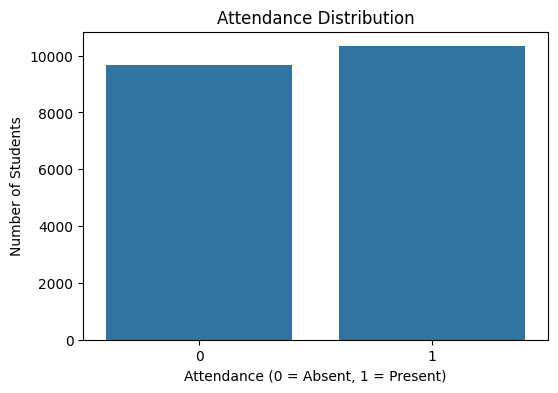

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Attendance distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='attendance', data=df)
plt.title('Attendance Distribution')
plt.xlabel('Attendance (0 = Absent, 1 = Present)')
plt.ylabel('Number of Students')
plt.show()

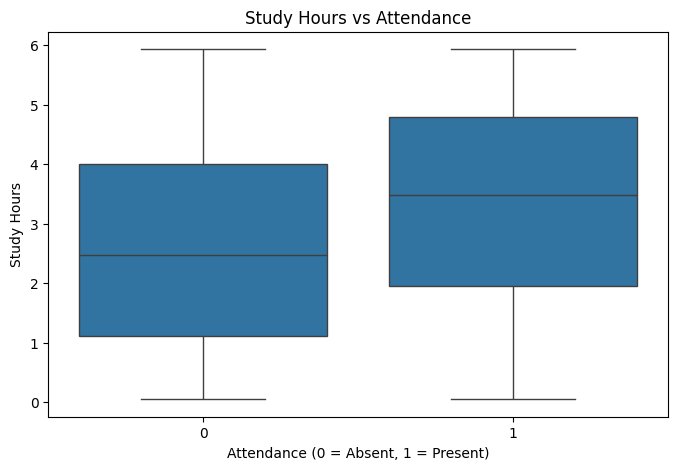

In [27]:
# Study hours vs attendance
plt.figure(figsize=(8, 5))
sns.boxplot(x='attendance', y='study_hours', data=df)
plt.title('Study Hours vs Attendance')
plt.xlabel('Attendance (0 = Absent, 1 = Present)')
plt.ylabel('Study Hours')
plt.show()

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Remove columns that should not be used for prediction
X = df.drop(columns=['attendance', 'student_id', 'absence_reason'])
y = df['attendance']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

print("Categorical columns:")
print(categorical_cols.tolist())

print("\nNumerical columns:")
print(numerical_cols.tolist())

# Convert categorical data into numerical form
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Categorical columns:
['gender', 'course', 'year', 'parent_education', 'internet_access', 'hostel_resident', 'class_type', 'weather']

Numerical columns:
['age', 'study_hours', 'sleep_hours', 'travel_time_minutes']

Training records: 16000
Testing records: 4000


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create the Random Forest model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model trained successfully!")
print(f"\nAccuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model trained successfully!

Accuracy: 60.45%

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.57      0.58      1935
           1       0.61      0.63      0.62      2065

    accuracy                           0.60      4000
   macro avg       0.60      0.60      0.60      4000
weighted avg       0.60      0.60      0.60      4000



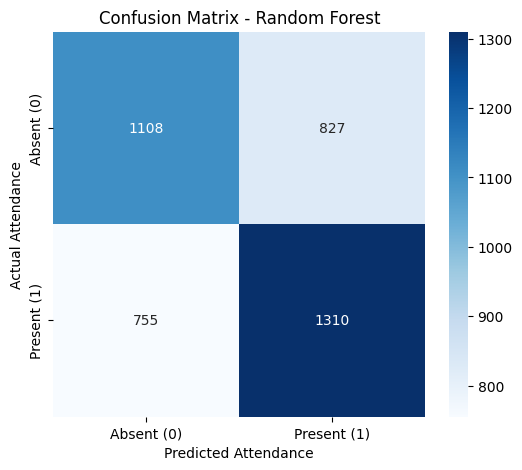

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Absent (0)', 'Present (1)'],
    yticklabels=['Absent (0)', 'Present (1)']
)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Attendance')
plt.ylabel('Actual Attendance')
plt.show()

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Create Logistic Regression model
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train the model
logistic_model.fit(X_train, y_train)

# Make predictions
logistic_pred = logistic_model.predict(X_test)

# Calculate accuracy
logistic_accuracy = accuracy_score(y_test, logistic_pred)

print("Logistic Regression trained successfully!")
print(f"\nAccuracy: {logistic_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, logistic_pred))

Logistic Regression trained successfully!

Accuracy: 61.92%

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.57      0.59      1935
           1       0.62      0.66      0.64      2065

    accuracy                           0.62      4000
   macro avg       0.62      0.62      0.62      4000
weighted avg       0.62      0.62      0.62      4000



In [32]:
print("MODEL COMPARISON")
print("----------------------------")
print(f"Random Forest       : {accuracy * 100:.2f}%")
print(f"Logistic Regression  : {logistic_accuracy * 100:.2f}%")

MODEL COMPARISON
----------------------------
Random Forest       : 60.45%
Logistic Regression  : 61.92%


In [33]:
# Create a sample student

new_student = pd.DataFrame({
    'age': [20],
    'gender': ['female'],
    'course': ['b.sc'],
    'year': ['2nd year'],
    'parent_education': ['graduate'],
    'internet_access': ['yes'],
    'hostel_resident': ['yes'],
    'class_type': ['offline'],
    'weather': ['sunny'],
    'study_hours': [4.0],
    'sleep_hours': [7.0],
    'travel_time_minutes': [20]
})

# Predict attendance
prediction = logistic_model.predict(new_student)[0]

# Get prediction probability
probability = logistic_model.predict_proba(new_student)[0]

if prediction == 1:
    result = "PRESENT"
else:
    result = "ABSENT"

print("===== SMART ATTENDANCE PREDICTION =====")
print("Predicted Attendance:", result)
print(f"Probability of Absent : {probability[0] * 100:.2f}%")
print(f"Probability of Present: {probability[1] * 100:.2f}%")

===== SMART ATTENDANCE PREDICTION =====
Predicted Attendance: PRESENT
Probability of Absent : 36.40%
Probability of Present: 63.60%


In [34]:
import joblib

# Save the trained model
joblib.dump(logistic_model, 'smart_attendance_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [35]:
# Final performance summary

print("==========================================")
print(" SMART ATTENDANCE PREDICTION SYSTEM")
print("==========================================")

print(f"Dataset Size        : {df.shape[0]} students")
print(f"Training Data       : {len(X_train)} students")
print(f"Testing Data        : {len(X_test)} students")

print("\nMODEL PERFORMANCE")
print("------------------------------------------")
print(f"Random Forest       : {accuracy * 100:.2f}%")
print(f"Logistic Regression : {logistic_accuracy * 100:.2f}%")

print("\nFINAL MODEL")
print("------------------------------------------")
print("Logistic Regression")

print("\nSAMPLE PREDICTION")
print("------------------------------------------")
print(f"Predicted Attendance : {result}")
print(f"Present Probability  : {probability[1] * 100:.2f}%")
print(f"Absent Probability   : {probability[0] * 100:.2f}%")

print("==========================================")

 SMART ATTENDANCE PREDICTION SYSTEM
Dataset Size        : 20000 students
Training Data       : 16000 students
Testing Data        : 4000 students

MODEL PERFORMANCE
------------------------------------------
Random Forest       : 60.45%
Logistic Regression : 61.92%

FINAL MODEL
------------------------------------------
Logistic Regression

SAMPLE PREDICTION
------------------------------------------
Predicted Attendance : PRESENT
Present Probability  : 63.60%
Absent Probability   : 36.40%
